<a href="https://colab.research.google.com/github/m-martinez92/web_Alojamendo/blob/Prueba/ClasificadorDeAvisos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
# # Clasificador de Avisos de Mantenimiento
#
# Este notebook implementa un sistema completo de clasificación de avisos de mantenimiento con:
# - Análisis exploratorio de datos
# - Preprocesamiento y ingeniería de características
# - Entrenamiento de múltiples modelos
# - Evaluación y selección del mejor modelo
# - Sistema de monitoreo y detección de drift
# - Seguimiento del rendimiento a lo largo del tiempo

# ## 1. Importación de Librerías

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime, timedelta
import joblib
import json
from scipy import stats

# Scikit-learn imports
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                           accuracy_score, precision_recall_fscore_support)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Configuraciones
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [27]:
# ## 2. Carga y Exploración de Datos
# Función de diagnóstico de datos
def diagnose_data_quality(df, target_col='Responsable Toma'):
    """Diagnosticar calidad de datos y problemas potenciales"""
    print("🔍 DIAGNÓSTICO DE CALIDAD DE DATOS")
    print("=" * 50)

    # Información básica
    print(f"📊 Forma del dataset: {df.shape}")
    print(f"🎯 Columna objetivo: {target_col}")

    # Verificar si existe la columna objetivo
    if target_col not in df.columns:
        print(f"❌ ERROR: La columna '{target_col}' no existe en los datos")
        print(f"Columnas disponibles: {list(df.columns)}")
        return False

    # Analizar variable objetivo
    target_stats = df[target_col].value_counts(dropna=False)
    print(f"\n📈 Distribución de la variable objetivo '{target_col}':")

    total_samples = len(df)
    problematic_classes = []

    for value, count in target_stats.items():
        percentage = (count / total_samples) * 100
        status = ""
        if pd.isna(value):
            status = " ⚠️  (VALOR NULO)"
        elif count == 1:
            status = " ❌ (UNA SOLA MUESTRA)"
            problematic_classes.append(value)
        elif count < 3:
            status = " ⚠️  (POCAS MUESTRAS)"
            problematic_classes.append(value)
        elif count < 5:
            status = " ⚡ (MUESTRAS LIMITADAS)"

        print(f"   {value}: {count} ({percentage:.1f}%){status}")

    # Recomendaciones
    print(f"\n💡 RECOMENDACIONES:")
    if problematic_classes:
        print(f"   ⚠️  Se encontraron {len(problematic_classes)} clases problemáticas")
        print(f"   🔧 Se filtrarán automáticamente durante el preprocesamiento")
        print(f"   📋 Clases a filtrar: {problematic_classes}")
    else:
        print(f"   ✅ Distribución de clases adecuada para el modelado")

    # Verificar valores nulos en general
    null_counts = df.isnull().sum()
    if null_counts.sum() > 0:
        print(f"   📝 Se encontraron valores nulos en {null_counts[null_counts > 0].shape[0]} columnas")
    else:
        print(f"   ✅ No se encontraron valores nulos")

    # Calcular clases utilizables
    usable_classes = target_stats[target_stats >= 3]
    print(f"\n📊 RESUMEN:")
    print(f"   • Clases totales: {len(target_stats)}")
    print(f"   • Clases utilizables (≥3 muestras): {len(usable_classes)}")
    print(f"   • Muestras totales: {total_samples}")
    print(f"   • Muestras utilizables: {usable_classes.sum()}")

    return len(usable_classes) >= 2  # Necesitamos al menos 2 clases para clasificación

# Cargar datos
def load_and_explore_data(file_path):
    """Cargar y realizar exploración inicial de los datos"""
    df = pd.read_csv(file_path, encoding='utf-8')

    print(f"📊 Dimensiones del dataset: {df.shape}")
    print(f"📋 Columnas: {list(df.columns)}")

    # Información básica
    print("\n" + "="*50)
    print("INFORMACIÓN BÁSICA DEL DATASET")
    print("="*50)
    print(df.info())

    # Valores nulos
    print("\n" + "="*30)
    print("VALORES NULOS POR COLUMNA")
    print("="*30)
    null_counts = df.isnull().sum()
    null_percentages = (null_counts / len(df)) * 100
    null_summary = pd.DataFrame({
        'Valores Nulos': null_counts,
        'Porcentaje': null_percentages
    })
    print(null_summary[null_summary['Valores Nulos'] > 0])

    return df

# Cargar datos
df = load_and_explore_data('Avisos.csv')

# Quitar columnas no utiles
df = df.drop(columns=['#', 'Fecha de Aviso', 'Numero de Aviso','Grupo Planificacion','Status Usuario Todos'])

# Diagnosticar calidad de datos
data_quality_ok = diagnose_data_quality(df, target_col='Responsable Toma')

if not data_quality_ok:
    print("❌ Los datos no son adecuados para el modelado. Revisar y corregir.")
    raise ValueError("Calidad de datos insuficiente")
else:
    print("✅ Los datos son adecuados para continuar con el modelado")

📊 Dimensiones del dataset: (189, 14)
📋 Columnas: ['#', 'Fecha de Aviso', 'Numero de Aviso', 'Ubicación Técnica', 'Clase de aviso', 'Prioridad', 'Texto Breve del Aviso', 'Área de empresa', 'Grupo Planificacion', 'Puesto de trabajo responsable', 'Status Usuario Todos', 'Emplazamiento', 'Activo Industrial', 'Responsable Toma']

INFORMACIÓN BÁSICA DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   #                              189 non-null    object
 1   Fecha de Aviso                 189 non-null    object
 2   Numero de Aviso                189 non-null    object
 3   Ubicación Técnica              189 non-null    object
 4   Clase de aviso                 189 non-null    object
 5   Prioridad                      189 non-null    object
 6   Texto Breve del Aviso          189 non-null    object
 7   Á

ValueError: Calidad de datos insuficiente

📈 DISTRIBUCIÓN DE 'Responsable Toma':
----------------------------------------
ESP: 188 (99.5%)
Responsable Toma: 1 (0.5%)


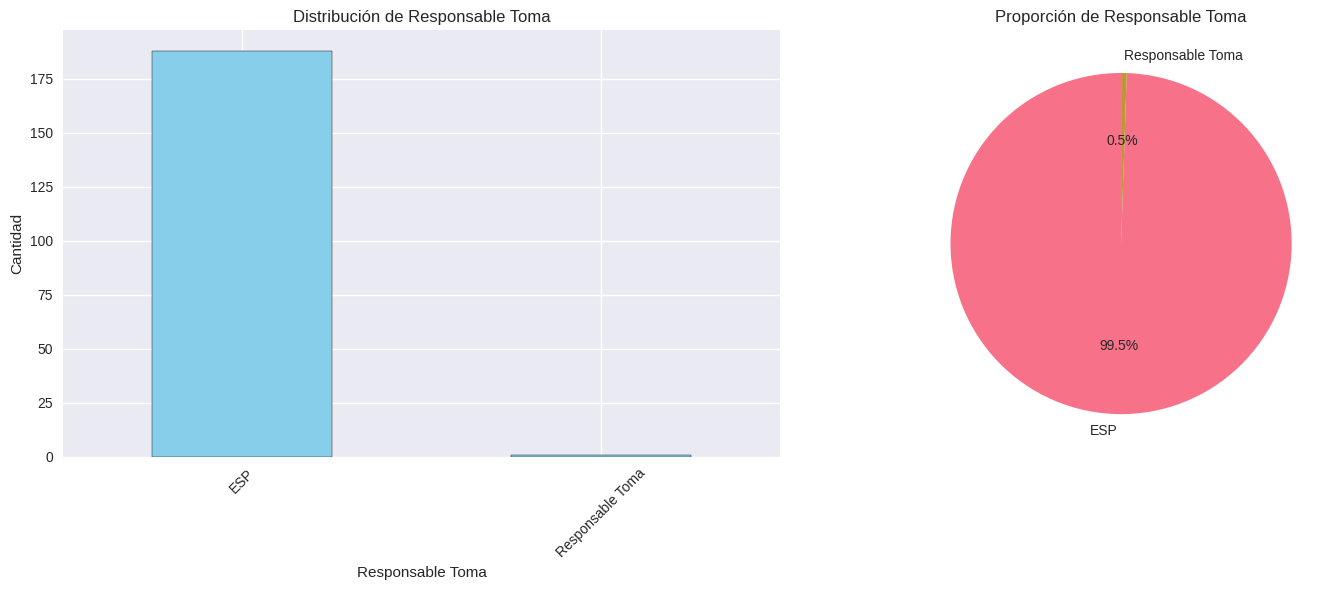

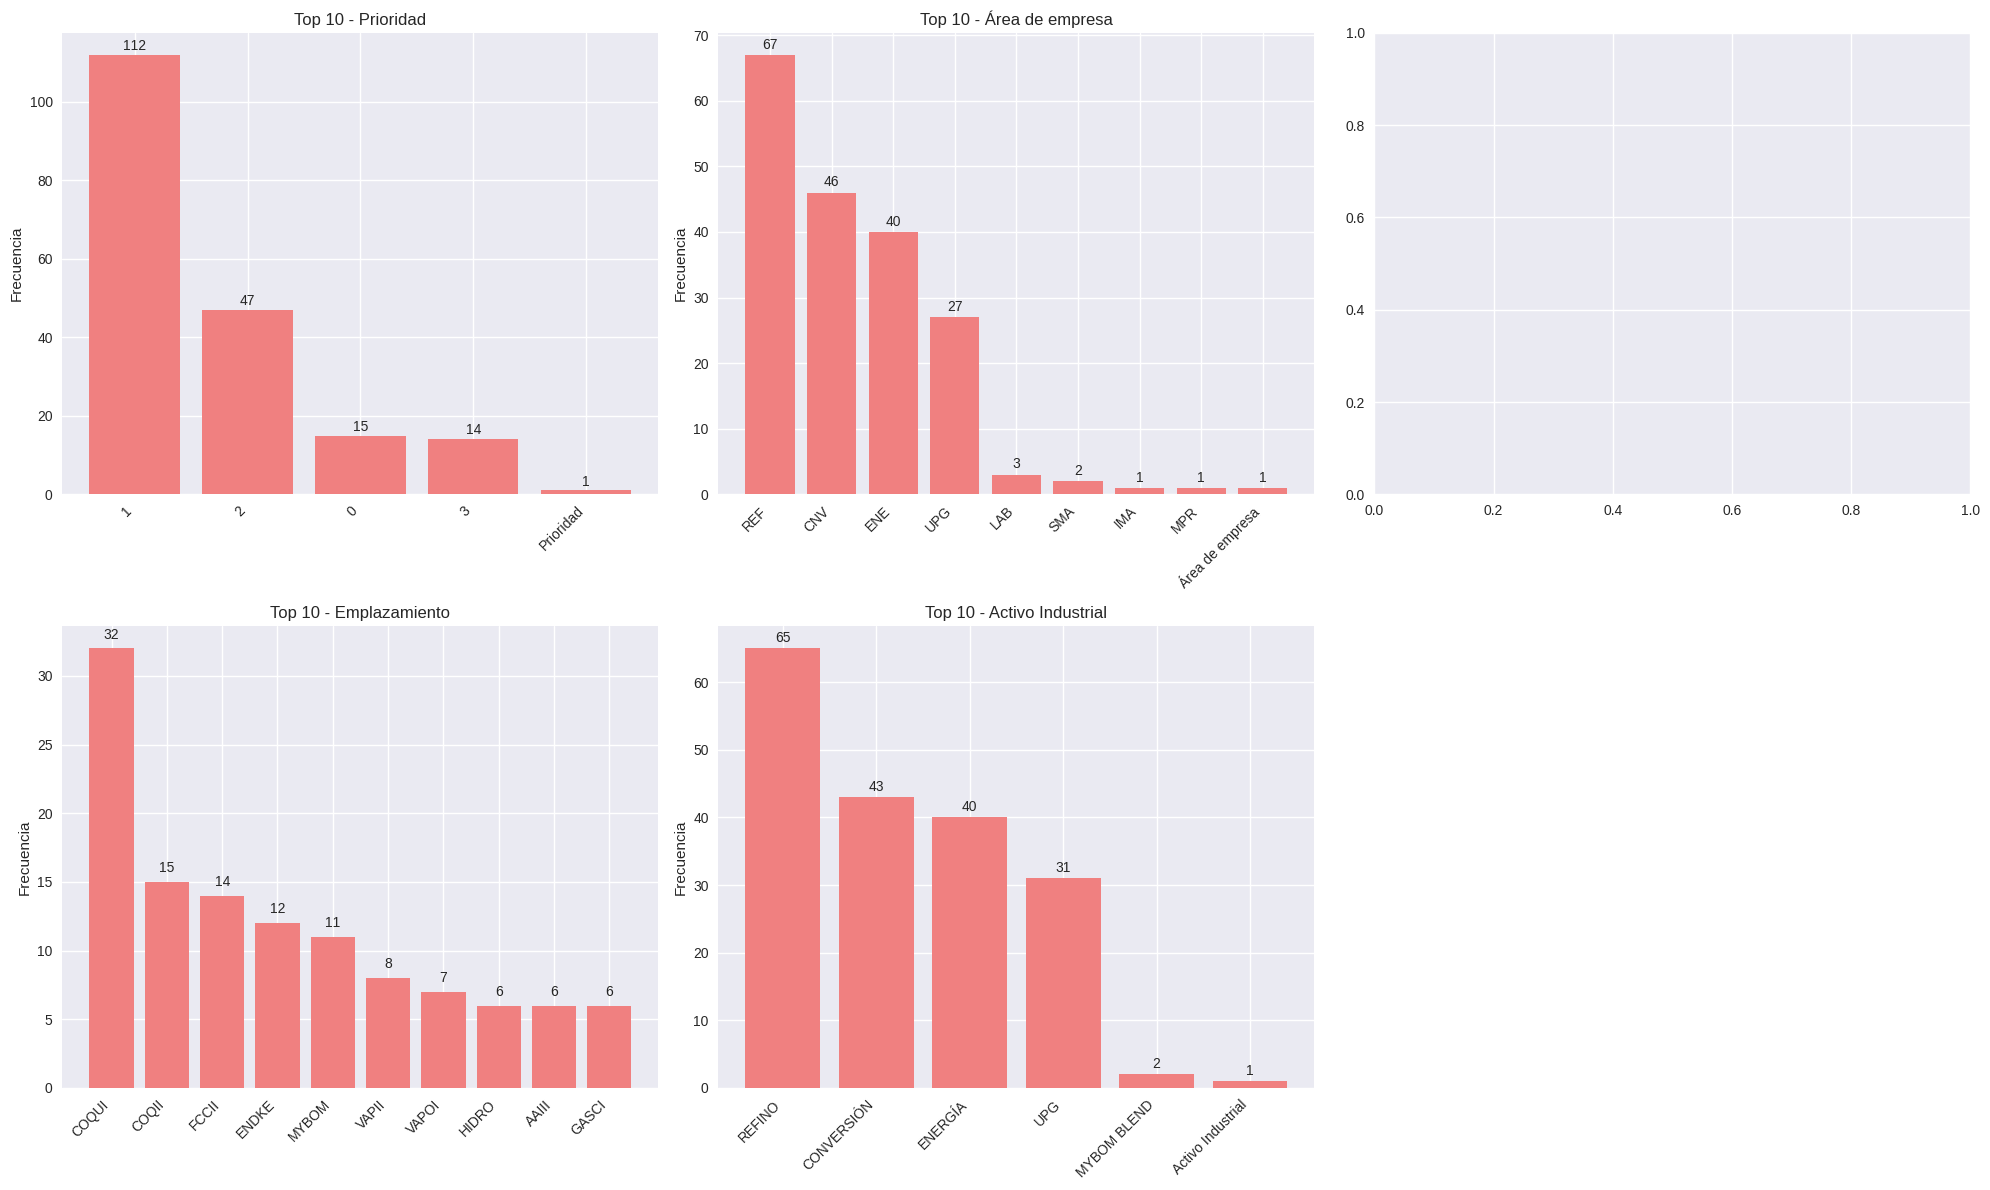

📝 ANÁLISIS DE TEXTO - 'Texto Breve del Aviso':
--------------------------------------------------
Longitud promedio: 29.8 caracteres
Palabras promedio: 4.8
Longitud mínima: 7 caracteres
Longitud máxima: 45 caracteres


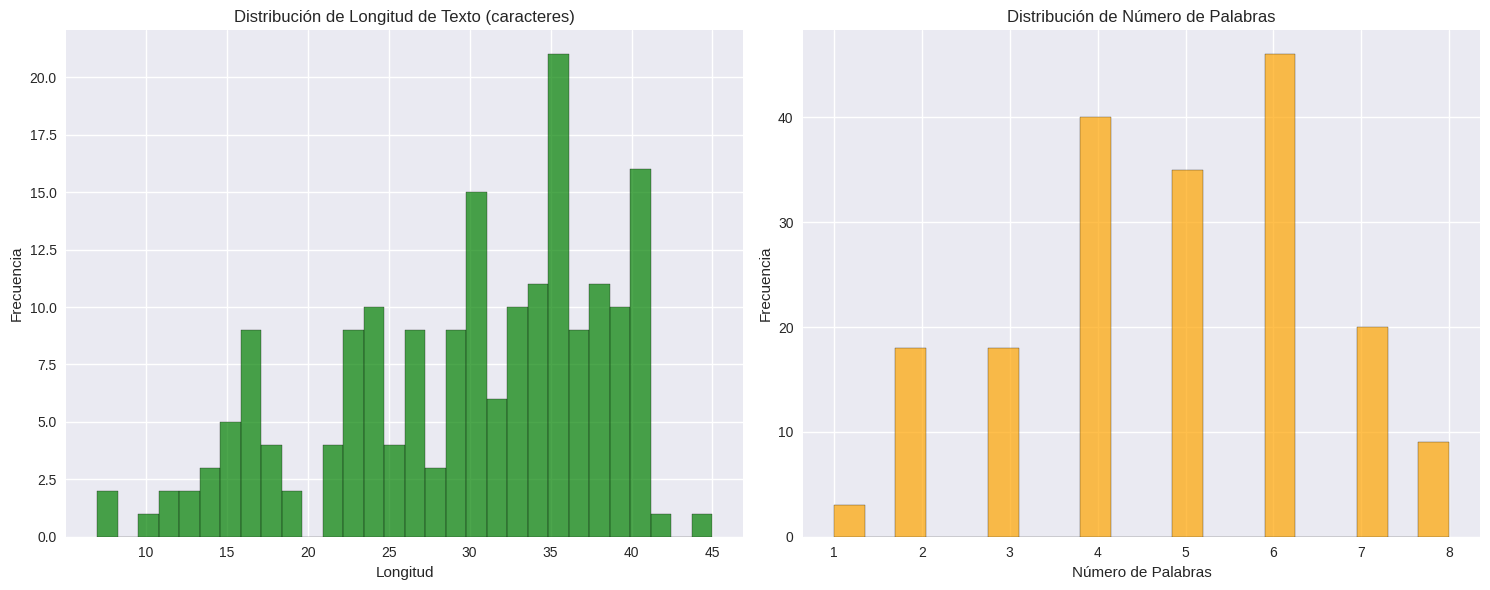

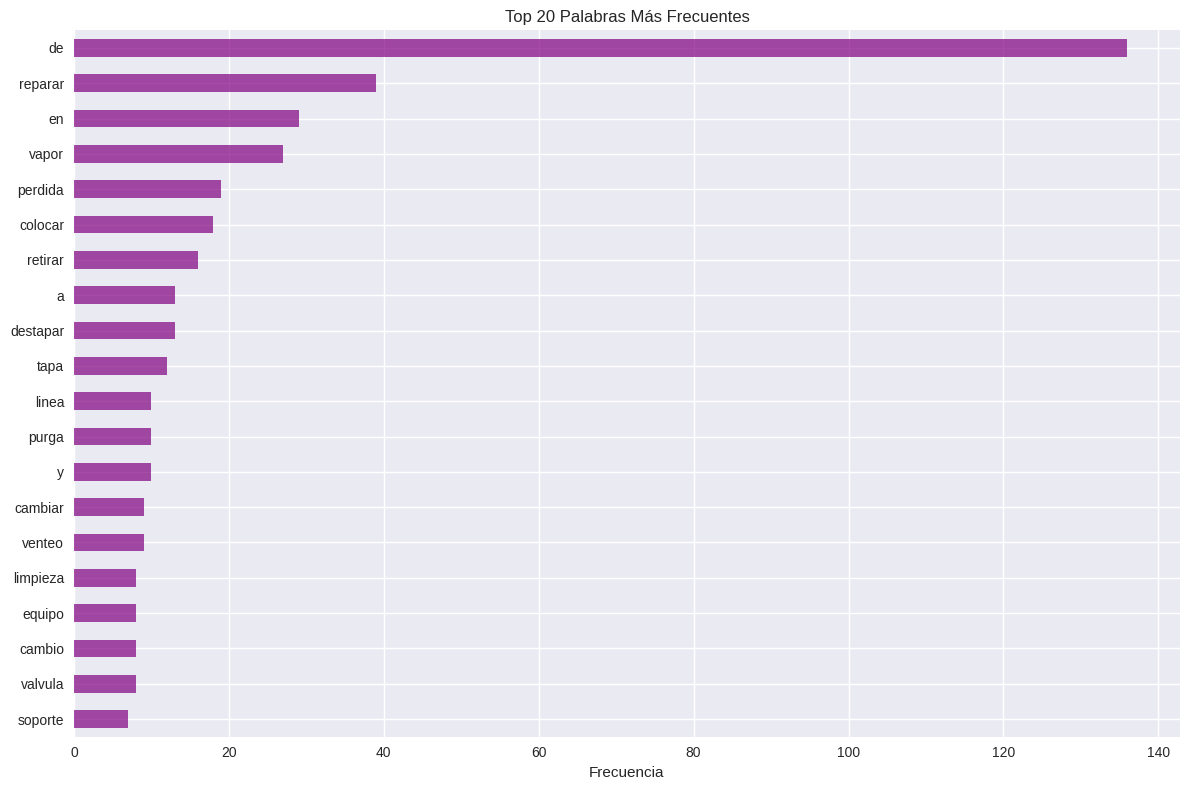

In [28]:
# Análisis de la variable objetivo
def analyze_target_variable(df, target_col='Responsable Toma'):
    """Analizar la distribución de la variable objetivo"""
    if target_col not in df.columns:
        print(f"❌ Columna '{target_col}' no encontrada")
        return

    # Distribución de clases
    class_counts = df[target_col].value_counts()

    print(f"📈 DISTRIBUCIÓN DE '{target_col}':")
    print("-" * 40)
    for class_name, count in class_counts.items():
        percentage = (count / len(df)) * 100
        print(f"{class_name}: {count} ({percentage:.1f}%)")

    # Visualización
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Gráfico de barras
    class_counts.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
    ax1.set_title(f'Distribución de {target_col}')
    ax1.set_ylabel('Cantidad')
    ax1.tick_params(axis='x', rotation=45)

    # Gráfico de pastel
    ax2.pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', startangle=90)
    ax2.set_title(f'Proporción de {target_col}')

    plt.tight_layout()
    plt.show()

    return class_counts

target_distribution = analyze_target_variable(df)

# %%
# Análisis de variables categóricas importantes
def analyze_categorical_variables(df):
    """Analizar variables categóricas importantes"""
    categorical_cols = ['Prioridad', 'Área de empresa', 'Status Usuario Todos',
                       'Emplazamiento', 'Activo Industrial']

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.ravel()

    for i, col in enumerate(categorical_cols):
        if col in df.columns and i < len(axes):
            value_counts = df[col].value_counts().head(10)  # Top 10

            axes[i].bar(range(len(value_counts)), value_counts.values, color='lightcoral')
            axes[i].set_title(f'Top 10 - {col}')
            axes[i].set_xticks(range(len(value_counts)))
            axes[i].set_xticklabels(value_counts.index, rotation=45, ha='right')
            axes[i].set_ylabel('Frecuencia')

            # Añadir etiquetas de valor
            for j, v in enumerate(value_counts.values):
                axes[i].text(j, v + 0.5, str(v), ha='center', va='bottom')

    # Ocultar subplot no usado
    if len(categorical_cols) < len(axes):
        axes[-1].set_visible(False)

    plt.tight_layout()
    plt.show()

analyze_categorical_variables(df)

# %%
# Análisis de texto
def analyze_text_data(df, text_col='Texto Breve del Aviso'):
    """Analizar características del texto"""
    if text_col not in df.columns:
        return

    # Limpiar y preparar texto
    text_data = df[text_col].fillna('').astype(str)

    # Estadísticas de longitud
    text_lengths = text_data.str.len()
    word_counts = text_data.str.split().str.len()

    print(f"📝 ANÁLISIS DE TEXTO - '{text_col}':")
    print("-" * 50)
    print(f"Longitud promedio: {text_lengths.mean():.1f} caracteres")
    print(f"Palabras promedio: {word_counts.mean():.1f}")
    print(f"Longitud mínima: {text_lengths.min()} caracteres")
    print(f"Longitud máxima: {text_lengths.max()} caracteres")

    # Visualización
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Histograma de longitudes
    ax1.hist(text_lengths, bins=30, alpha=0.7, color='green', edgecolor='black')
    ax1.set_title('Distribución de Longitud de Texto (caracteres)')
    ax1.set_xlabel('Longitud')
    ax1.set_ylabel('Frecuencia')

    # Histograma de número de palabras
    ax2.hist(word_counts.dropna(), bins=20, alpha=0.7, color='orange', edgecolor='black')
    ax2.set_title('Distribución de Número de Palabras')
    ax2.set_xlabel('Número de Palabras')
    ax2.set_ylabel('Frecuencia')

    plt.tight_layout()
    plt.show()

    # Palabras más comunes
    all_words = ' '.join(text_data).lower().split()
    word_freq = pd.Series(all_words).value_counts().head(20)

    plt.figure(figsize=(12, 8))
    word_freq.plot(kind='barh', color='purple', alpha=0.7)
    plt.title('Top 20 Palabras Más Frecuentes')
    plt.xlabel('Frecuencia')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

analyze_text_data(df)


In [17]:
# ## 4. Preprocesamiento de Datos
class DataPreprocessor:
    """Clase para preprocesamiento de datos de avisos de mantenimiento"""

    def __init__(self, target_column='Responsable Toma'):
        self.target_column = target_column
        self.label_encoder = None
        self.preprocessor = None
        self.tfidf_vectorizer = None
        self.feature_names = []

    def prepare_features(self, df):
        """Preparar características para el modelo"""
        print("🔧 Iniciando preprocesamiento...")

        # Crear copia del DataFrame
        df_processed = df.copy()

        # Limpiar datos
        df_processed = df_processed.dropna(subset=[self.target_column])
        print(f"Filas después de limpiar target: {len(df_processed)}")

        # Analizar distribución de clases antes del procesamiento
        class_distribution = df_processed[self.target_column].value_counts()
        print(f"\n📊 Distribución de clases:")
        for clase, count in class_distribution.items():
            print(f"   {clase}: {count} muestras")

        # Filtrar clases con muy pocas muestras (menos de 3)
        min_samples_per_class = 3
        classes_to_keep = class_distribution[class_distribution >= min_samples_per_class].index

        if len(classes_to_keep) < len(class_distribution):
            removed_classes = class_distribution[class_distribution < min_samples_per_class]
            print(f"\n⚠️  Eliminando clases con menos de {min_samples_per_class} muestras:")
            for clase, count in removed_classes.items():
                print(f"   {clase}: {count} muestras")

            df_processed = df_processed[df_processed[self.target_column].isin(classes_to_keep)]
            print(f"Filas después de filtrar clases: {len(df_processed)}")

        # Procesar fechas
        if 'Fecha de Aviso' in df_processed.columns:
            df_processed['Fecha de Aviso'] = pd.to_datetime(
                df_processed['Fecha de Aviso'], format='%d/%m/%Y', errors='coerce'
            )
            df_processed['Mes'] = df_processed['Fecha de Aviso'].dt.month
            df_processed['Dia_Semana'] = df_processed['Fecha de Aviso'].dt.dayofweek
            df_processed['Trimestre'] = df_processed['Fecha de Aviso'].dt.quarter

        # Definir tipos de características
        numeric_features = []
        if 'Prioridad' in df_processed.columns:
            numeric_features.append('Prioridad')
        if 'Mes' in df_processed.columns:
            numeric_features.extend(['Mes', 'Dia_Semana', 'Trimestre'])

        categorical_features = [
            col for col in [
                'Ubicación Técnica', 'Área de empresa', 'Grupo Planificacion',
                'Puesto de trabajo responsable', 'Status Usuario Todos',
                'Emplazamiento', 'Activo Industrial', 'Responsable Toma'
            ] if col in df_processed.columns
        ]

        text_features = [
            col for col in ['Texto Breve del Aviso'] if col in df_processed.columns
        ]

        print(f"Características numéricas: {numeric_features}")
        print(f"Características categóricas: {len(categorical_features)}")
        print(f"Características de texto: {text_features}")

        # Crear transformadores
        transformers = []

        if numeric_features:
            transformers.append(('num', StandardScaler(), numeric_features))

        if categorical_features:
            transformers.append(
                ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
                 categorical_features)
            )

        # Crear preprocessor para características estructuradas
        if transformers:
            self.preprocessor = ColumnTransformer(
                transformers=transformers,
                remainder='drop'
            )

        # Preparar características
        X_parts = []
        feature_names = []

        # Características estructuradas
        if self.preprocessor:
            X_structured = self.preprocessor.fit_transform(df_processed)
            X_parts.append(X_structured)

            # Obtener nombres de características
            if hasattr(self.preprocessor, 'get_feature_names_out'):
                feature_names.extend(self.preprocessor.get_feature_names_out())
            else:
                # Aproximación para versiones anteriores
                n_features = X_structured.shape[1]
                feature_names.extend([f'feature_{i}' for i in range(n_features)])

        # Características de texto
        if text_features:
            self.tfidf_vectorizer = TfidfVectorizer(
                max_features=100,
                ngram_range=(1, 2),
                min_df=2,
                stop_words=None  # Mantener stop words en español
            )

            text_data = df_processed[text_features[0]].fillna('').astype(str)
            X_text = self.tfidf_vectorizer.fit_transform(text_data).toarray()
            X_parts.append(X_text)

            # Nombres de características de texto
            if hasattr(self.tfidf_vectorizer, 'get_feature_names_out'):
                text_feature_names = self.tfidf_vectorizer.get_feature_names_out()
            else:
                text_feature_names = [f'tfidf_{i}' for i in range(X_text.shape[1])]
            feature_names.extend(text_feature_names)

        # Combinar características
        if X_parts:
            X = np.hstack(X_parts)
        else:
            raise ValueError("No se pudieron crear características válidas")

        # Preparar variable objetivo
        self.label_encoder = LabelEncoder()
        y = self.label_encoder.fit_transform(df_processed[self.target_column])

        self.feature_names = feature_names

        print(f"✅ Preprocesamiento completado:")
        print(f"   - Matriz X: {X.shape}")
        print(f"   - Vector y: {y.shape}")
        print(f"   - Clases: {list(self.label_encoder.classes_)}")

        return X, y, df_processed

    def transform_new_data(self, df_new):
        """Transformar nuevos datos usando los transformadores entrenados"""
        X_parts = []

        # Procesar fechas si existen
        if 'Fecha de Aviso' in df_new.columns:
            df_new = df_new.copy()
            df_new['Fecha de Aviso'] = pd.to_datetime(
                df_new['Fecha de Aviso'], format='%d/%m/%Y', errors='coerce'
            )
            df_new['Mes'] = df_new['Fecha de Aviso'].dt.month
            df_new['Dia_Semana'] = df_new['Fecha de Aviso'].dt.dayofweek
            df_new['Trimestre'] = df_new['Fecha de Aviso'].dt.quarter

        # Características estructuradas
        if self.preprocessor:
            X_structured = self.preprocessor.transform(df_new)
            X_parts.append(X_structured)

        # Características de texto
        if self.tfidf_vectorizer and 'Texto Breve del Aviso' in df_new.columns:
            text_data = df_new['Texto Breve del Aviso'].fillna('').astype(str)
            X_text = self.tfidf_vectorizer.transform(text_data).toarray()
            X_parts.append(X_text)

        return np.hstack(X_parts) if X_parts else np.array([])

# Crear preprocessor y preparar datos
preprocessor = DataPreprocessor(target_column='Responsable Toma')
X, y, df_clean = preprocessor.prepare_features(df)

🔧 Iniciando preprocesamiento...
Filas después de limpiar target: 189

📊 Distribución de clases:
   D2: 164 muestras
   D1: 21 muestras
   D5: 3 muestras
   Clase de aviso: 1 muestras

⚠️  Eliminando clases con menos de 3 muestras:
   Clase de aviso: 1 muestras
Filas después de filtrar clases: 188
Características numéricas: ['Prioridad']
Características categóricas: 6
Características de texto: ['Texto Breve del Aviso']
✅ Preprocesamiento completado:
   - Matriz X: (188, 280)
   - Vector y: (188,)
   - Clases: ['D1', 'D2', 'D5']


🚀 Iniciando entrenamiento de modelos...
📊 Distribución de clases:
   Clase 0: 21 muestras
   Clase 1: 164 muestras
   Clase 2: 3 muestras
✅ Usando división estratificada.
📊 División de datos:
   - Entrenamiento: 150 muestras
   - Prueba: 38 muestras

⏳ Entrenando RandomForest...
✅ RandomForest completado:
   - Train Acc: 1.0000
   - Test Acc: 0.9474
   - CV: 0.9133 ± 0.0067

⏳ Entrenando GradientBoosting...
✅ GradientBoosting completado:
   - Train Acc: 1.0000
   - Test Acc: 0.9211
   - CV: 0.9133 ± 0.0067

⏳ Entrenando LogisticRegression...
✅ LogisticRegression completado:
   - Train Acc: 0.9933
   - Test Acc: 0.8947
   - CV: 0.8600 ± 0.0067

⏳ Entrenando SVM...
✅ SVM completado:
   - Train Acc: 0.9867
   - Test Acc: 0.8947
   - CV: 0.8800 ± 0.0000

🏆 MEJOR MODELO: RandomForest
   Accuracy: 0.9474


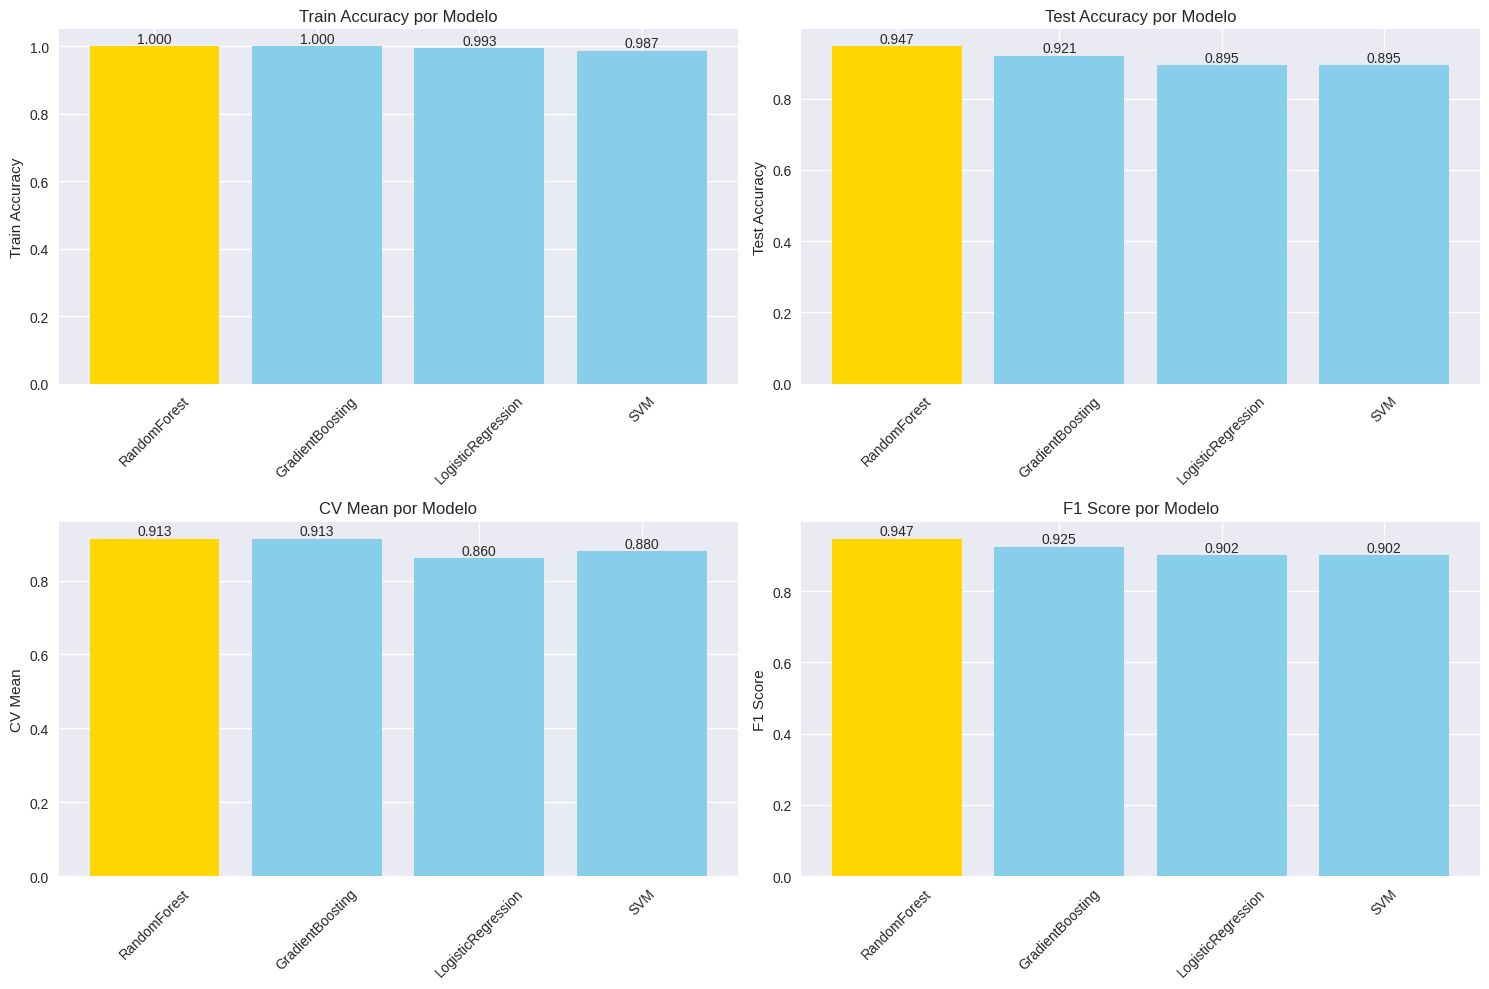

In [18]:
class ModelTrainer:
    """Clase para entrenar y evaluar múltiples modelos"""

    def __init__(self, random_state=42):
        self.random_state = random_state
        self.models = {}
        self.results = {}
        self.best_model = None
        self.best_model_name = None

    def prepare_models(self):
        """Definir modelos a entrenar"""
        self.models = {
            'RandomForest': RandomForestClassifier(
                n_estimators=100,
                random_state=self.random_state,
                class_weight='balanced'
            ),
            'GradientBoosting': GradientBoostingClassifier(
                random_state=self.random_state
            ),
            'LogisticRegression': LogisticRegression(
                random_state=self.random_state,
                max_iter=1000,
                class_weight='balanced'
            ),
            'SVM': SVC(
                random_state=self.random_state,
                probability=True,
                class_weight='balanced'
            )
        }

    def train_and_evaluate(self, X, y, test_size=0.2):
        """Entrenar todos los modelos y evaluarlos"""
        print("🚀 Iniciando entrenamiento de modelos...")

        # Verificar distribución de clases
        unique_classes, class_counts = np.unique(y, return_counts=True)
        min_class_count = np.min(class_counts)

        print(f"📊 Distribución de clases:")
        for cls, count in zip(unique_classes, class_counts):
            print(f"   Clase {cls}: {count} muestras")

        # Decidir si usar estratificación
        if min_class_count < 2:
            print("⚠️  Algunas clases tienen muy pocas muestras. Deshabilitando estratificación.")
            stratify_param = None

            # Filtrar clases con una sola muestra para evitar problemas
            if min_class_count == 1:
                print("🔧 Filtrando clases con una sola muestra...")
                mask = np.isin(y, unique_classes[class_counts > 1])
                X = X[mask]
                y = y[mask]
                print(f"   Datos después del filtrado: {X.shape[0]} muestras")
        else:
            stratify_param = y
            print("✅ Usando división estratificada.")

        # Dividir datos
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=self.random_state,
            stratify=stratify_param
        )

        self.X_train, self.X_test = X_train, X_test
        self.y_train, self.y_test = y_train, y_test

        print(f"📊 División de datos:")
        print(f"   - Entrenamiento: {X_train.shape[0]} muestras")
        print(f"   - Prueba: {X_test.shape[0]} muestras")

        # Preparar modelos con configuraciones adaptativas
        self.prepare_models()

        # Verificar si el dataset es muy pequeño
        is_small_dataset = len(X_train) < 100
        if is_small_dataset:
            print("📏 Dataset pequeño detectado. Ajustando configuración de modelos...")
            # Reducir complejidad para datasets pequeños
            self.models['RandomForest'].n_estimators = 50
            if 'SVM' in self.models:
                # Para datasets muy pequeños, remover SVM que puede ser problemático
                if len(X_train) < 50:
                    del self.models['SVM']
                    print("   🔧 Removiendo SVM para dataset muy pequeño")

        # Entrenar cada modelo
        for name, model in self.models.items():
            print(f"\n⏳ Entrenando {name}...")

            # Entrenar
            model.fit(X_train, y_train)

            # Predicciones
            train_pred = model.predict(X_train)
            test_pred = model.predict(X_test)
            test_proba = model.predict_proba(X_test)

            # Métricas
            train_acc = accuracy_score(y_train, train_pred)
            test_acc = accuracy_score(y_test, test_pred)

            # Validación cruzada con manejo de clases pequeñas
            try:
                # Verificar si es posible hacer CV con 5 folds
                min_class_samples = np.min(np.bincount(y_train))
                cv_folds = min(5, min_class_samples) if min_class_samples >= 2 else 2

                if cv_folds < 2:
                    print(f"   ⚠️  Saltando CV para {name} (muy pocas muestras)")
                    cv_scores = np.array([test_acc])  # Usar test accuracy como proxy
                else:
                    cv_scores = cross_val_score(
                        model, X_train, y_train, cv=cv_folds, scoring='accuracy'
                    )
            except Exception as e:
                print(f"   ⚠️  Error en CV para {name}: {e}")
                cv_scores = np.array([test_acc])  # Usar test accuracy como proxy

            # Métricas detalladas
            precision, recall, f1, _ = precision_recall_fscore_support(
                y_test, test_pred, average='weighted'
            )

            # Guardar resultados
            self.results[name] = {
                'model': model,
                'train_accuracy': train_acc,
                'test_accuracy': test_acc,
                'cv_mean': cv_scores.mean(),
                'cv_std': cv_scores.std(),
                'precision': precision,
                'recall': recall,
                'f1_score': f1,
                'predictions': test_pred,
                'probabilities': test_proba
            }

            print(f"✅ {name} completado:")
            print(f"   - Train Acc: {train_acc:.4f}")
            print(f"   - Test Acc: {test_acc:.4f}")
            print(f"   - CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

        # Seleccionar mejor modelo
        self.select_best_model()

        return self.results

    def select_best_model(self):
        """Seleccionar el mejor modelo basado en accuracy de prueba"""
        best_score = -1
        for name, result in self.results.items():
            if result['test_accuracy'] > best_score:
                best_score = result['test_accuracy']
                self.best_model_name = name
                self.best_model = result['model']

        print(f"\n🏆 MEJOR MODELO: {self.best_model_name}")
        print(f"   Accuracy: {best_score:.4f}")

    def plot_model_comparison(self):
        """Graficar comparación de modelos"""
        model_names = list(self.results.keys())
        metrics = ['train_accuracy', 'test_accuracy', 'cv_mean', 'f1_score']
        metric_labels = ['Train Accuracy', 'Test Accuracy', 'CV Mean', 'F1 Score']

        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        axes = axes.ravel()

        for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
            values = [self.results[name][metric] for name in model_names]

            bars = axes[i].bar(model_names, values,
                              color=['gold' if name == self.best_model_name else 'skyblue'
                                    for name in model_names])
            axes[i].set_title(f'{label} por Modelo')
            axes[i].set_ylabel(label)
            axes[i].tick_params(axis='x', rotation=45)

            # Añadir valores en las barras
            for bar, val in zip(bars, values):
                axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                           f'{val:.3f}', ha='center', va='bottom')

        plt.tight_layout()
        plt.show()

# Entrenar modelos
trainer = ModelTrainer(random_state=42)
training_results = trainer.train_and_evaluate(X, y, test_size=0.2)

# Mostrar comparación
trainer.plot_model_comparison()

📋 EVALUACIÓN DETALLADA - RandomForest

📊 REPORTE DE CLASIFICACIÓN:
----------------------------------------
              precision    recall  f1-score   support

          D1       0.75      0.75      0.75         4
          D2       0.97      0.97      0.97        33
          D5       1.00      1.00      1.00         1

    accuracy                           0.95        38
   macro avg       0.91      0.91      0.91        38
weighted avg       0.95      0.95      0.95        38



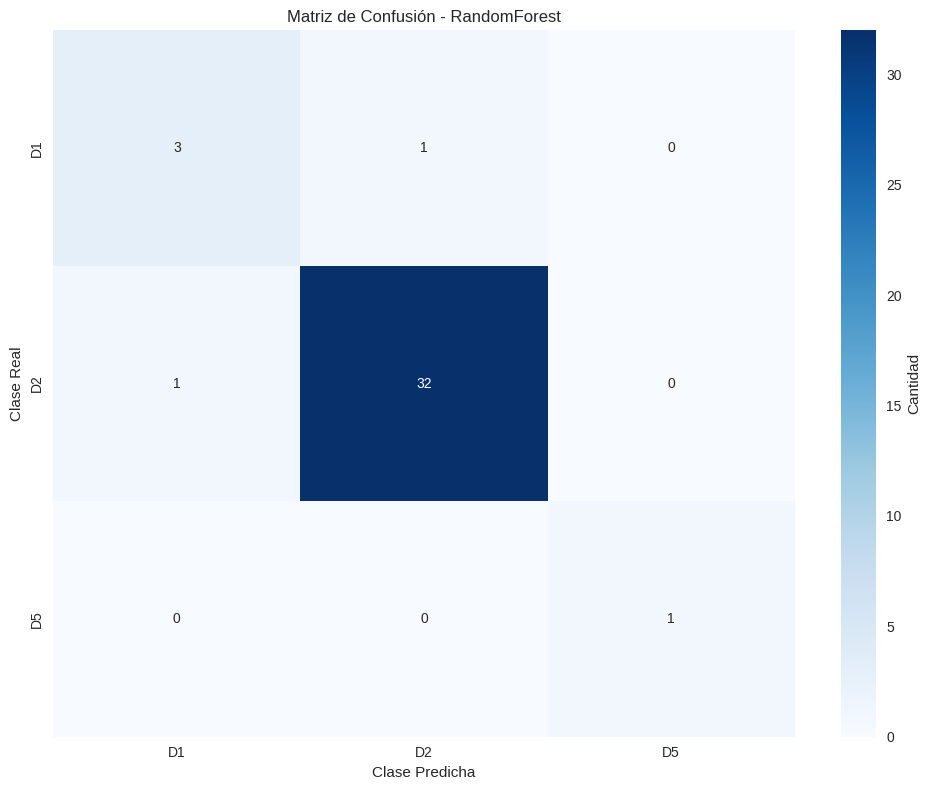

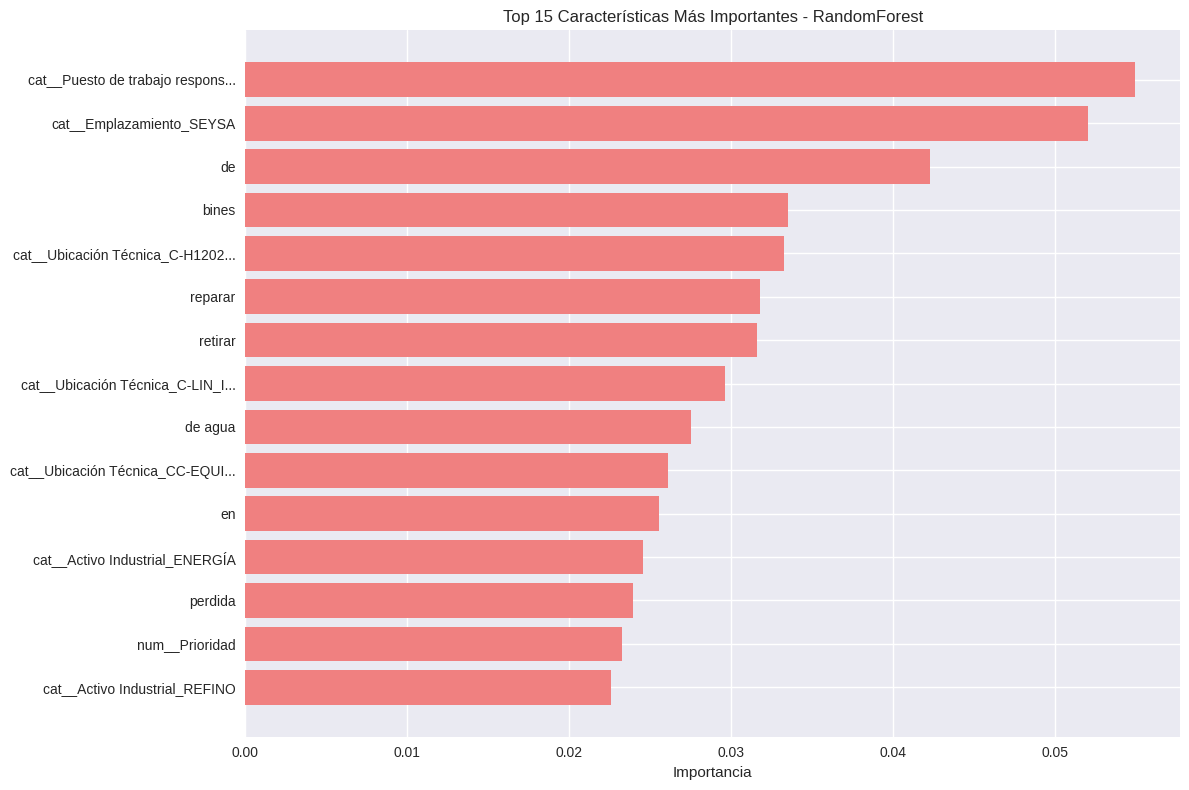

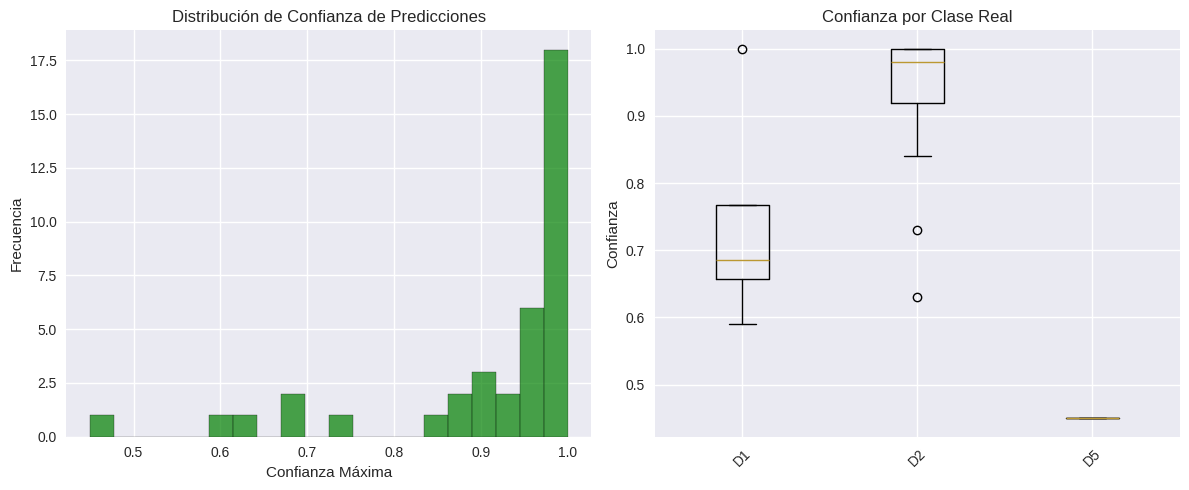

📏 Estableciendo baseline del modelo...
✅ Baseline establecido:
   - Accuracy: 0.9474
   - Confianza promedio: 0.9116
   - Tamaño de muestra: 38


In [19]:
# ## 6. Evaluación Detallada del Mejor Modelo

# %%
def evaluate_best_model(trainer, preprocessor):
    """Evaluación detallada del mejor modelo"""
    best_model = trainer.best_model
    best_name = trainer.best_model_name

    print(f"📋 EVALUACIÓN DETALLADA - {best_name}")
    print("="*60)

    # Predicciones del mejor modelo
    y_pred = best_model.predict(trainer.X_test)
    y_proba = best_model.predict_proba(trainer.X_test)

    # Reporte de clasificación
    target_names = preprocessor.label_encoder.classes_
    print("\n📊 REPORTE DE CLASIFICACIÓN:")
    print("-" * 40)
    print(classification_report(trainer.y_test, y_pred, target_names=target_names))

    # Matriz de confusión
    cm = confusion_matrix(trainer.y_test, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=target_names, yticklabels=target_names,
               cbar_kws={'label': 'Cantidad'})
    plt.title(f'Matriz de Confusión - {best_name}')
    plt.ylabel('Clase Real')
    plt.xlabel('Clase Predicha')
    plt.tight_layout()
    plt.show()

    # Importancia de características (si aplica)
    if hasattr(best_model, 'feature_importances_'):
        plot_feature_importance(best_model, best_name, preprocessor.feature_names)

    # Distribución de confianza
    max_probabilities = np.max(y_proba, axis=1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.hist(max_probabilities, bins=20, alpha=0.7, color='green', edgecolor='black')
    plt.title('Distribución de Confianza de Predicciones')
    plt.xlabel('Confianza Máxima')
    plt.ylabel('Frecuencia')

    plt.subplot(1, 2, 2)
    plt.boxplot([max_probabilities[trainer.y_test == i] for i in range(len(target_names))],
               labels=target_names)
    plt.title('Confianza por Clase Real')
    plt.ylabel('Confianza')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

    return {
        'model': best_model,
        'predictions': y_pred,
        'probabilities': y_proba,
        'confidence_mean': np.mean(max_probabilities),
        'confidence_std': np.std(max_probabilities)
    }

def plot_feature_importance(model, model_name, feature_names, top_n=15):
    """Graficar importancia de características"""
    importance = model.feature_importances_
    indices = np.argsort(importance)[::-1][:top_n]

    plt.figure(figsize=(12, 8))
    plt.title(f'Top {top_n} Características Más Importantes - {model_name}')

    # Usar nombres de características si están disponibles
    if feature_names and len(feature_names) >= len(importance):
        labels = [feature_names[i] for i in indices]
    else:
        labels = [f'Feature_{i}' for i in indices]

    # Truncar etiquetas largas
    labels = [label[:30] + '...' if len(label) > 30 else label for label in labels]

    plt.barh(range(top_n), importance[indices], color='lightcoral')
    plt.yticks(range(top_n), labels)
    plt.xlabel('Importancia')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# Evaluar mejor modelo
evaluation_results = evaluate_best_model(trainer, preprocessor)



In [20]:
# ## 7. Sistema de Monitoreo y Detección de Drift

# %%
class ModelMonitor:
    """Sistema de monitoreo para detectar drift y degradación del modelo"""

    def __init__(self, model, preprocessor):
        self.model = model
        self.preprocessor = preprocessor
        self.baseline_metrics = {}
        self.monitoring_history = []
        self.alert_thresholds = {
            'accuracy_drop': 0.05,    # 5% caída en accuracy
            'confidence_drop': 0.1,   # 10% caída en confianza
            'distribution_change': 0.1 # Cambio en distribución
        }

    def establish_baseline(self, X_baseline, y_baseline):
        """Establecer métricas baseline"""
        print("📏 Estableciendo baseline del modelo...")

        y_pred = self.model.predict(X_baseline)
        y_proba = self.model.predict_proba(X_baseline)

        # Métricas básicas
        accuracy = accuracy_score(y_baseline, y_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_baseline, y_pred, average='weighted'
        )

        # Distribución de predicciones
        unique, counts = np.unique(y_pred, return_counts=True)
        pred_distribution = counts / len(y_pred)

        # Confianza de predicciones
        max_probabilities = np.max(y_proba, axis=1)
        confidence_mean = np.mean(max_probabilities)
        confidence_std = np.std(max_probabilities)

        # Estadísticas de características
        feature_stats = {
            'mean': np.mean(X_baseline, axis=0),
            'std': np.std(X_baseline, axis=0),
            'percentiles': {
                25: np.percentile(X_baseline, 25, axis=0),
                50: np.percentile(X_baseline, 50, axis=0),
                75: np.percentile(X_baseline, 75, axis=0)
            }
        }

        self.baseline_metrics = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'prediction_distribution': pred_distribution,
            'confidence_mean': confidence_mean,
            'confidence_std': confidence_std,
            'feature_statistics': feature_stats,
            'sample_size': len(X_baseline)
        }

        print(f"✅ Baseline establecido:")
        print(f"   - Accuracy: {accuracy:.4f}")
        print(f"   - Confianza promedio: {confidence_mean:.4f}")
        print(f"   - Tamaño de muestra: {len(X_baseline)}")

    def detect_data_drift(self, X_new, method='percentile_check'):
        """Detectar drift en las características"""
        print("🔍 Detectando drift en datos...")

        if not self.baseline_metrics:
            raise ValueError("Debe establecer baseline primero")

        baseline_stats = self.baseline_metrics['feature_statistics']
        drift_indicators = []

        # Método basado en percentiles
        if method == 'percentile_check':
            baseline_25 = baseline_stats['percentiles'][25]
            baseline_75 = baseline_stats['percentiles'][75]

            for feature_idx in range(X_new.shape[1]):
                new_feature = X_new[:, feature_idx]

                # Porcentaje de valores fuera del rango intercuartil baseline
                outside_range = np.sum(
                    (new_feature < baseline_25[feature_idx]) |
                    (new_feature > baseline_75[feature_idx])
                ) / len(new_feature)

                # Si más del 60% está fuera del rango IQR, hay drift
                drift_detected = outside_range > 0.6
                drift_indicators.append(drift_detected)

        drift_percentage = np.mean(drift_indicators) * 100
        features_with_drift = np.sum(drift_indicators)

        print(f"📊 Drift detectado en {features_with_drift}/{len(drift_indicators)} características ({drift_percentage:.1f}%)")

        return {
            'features_with_drift': features_with_drift,
            'total_features': len(drift_indicators),
            'drift_percentage': drift_percentage,
            'drift_indicators': drift_indicators,
            'severe_drift': drift_percentage > 25  # Más del 25% de características con drift
        }

    def detect_prediction_drift(self, X_new):
        """Detectar drift en predicciones"""
        print("🎯 Detectando drift en predicciones...")

        y_pred_new = self.model.predict(X_new)
        y_proba_new = self.model.predict_proba(X_new)

        # Distribución de nuevas predicciones
        unique, counts = np.unique(y_pred_new, return_counts=True)
        new_pred_distribution = counts / len(y_pred_new)

        # Comparar con distribución baseline
        baseline_dist = self.baseline_metrics['prediction_distribution']

        # Asegurar que ambas distribuciones tengan la misma longitud
        max_len = max(len(baseline_dist), len(new_pred_distribution))
        baseline_padded = np.pad(baseline_dist, (0, max_len - len(baseline_dist)))
        new_padded = np.pad(new_pred_distribution, (0, max_len - len(new_pred_distribution)))

        # Distancia entre distribuciones (Jensen-Shannon)
        def js_divergence(p, q):
            """Jensen-Shannon divergence"""
            p = p + 1e-10  # Evitar log(0)
            q = q + 1e-10
            m = 0.5 * (p + q)
            return 0.5 * np.sum(p * np.log(p / m)) + 0.5 * np.sum(q * np.log(q / m))

        js_div = js_divergence(baseline_padded, new_padded)

        # Comparar confianza
        new_confidence_mean = np.mean(np.max(y_proba_new, axis=1))
        baseline_confidence = self.baseline_metrics['confidence_mean']
        confidence_change = abs(new_confidence_mean - baseline_confidence) / baseline_confidence

        prediction_drift_detected = (
            js_div > self.alert_thresholds['distribution_change'] or
            confidence_change > self.alert_thresholds['confidence_drop']
        )

        print(f"📈 JS Divergence: {js_div:.4f}")
        print(f"📊 Cambio en confianza: {confidence_change*100:.1f}%")

        return {
            'js_divergence': js_div,
            'confidence_change': confidence_change,
            'new_confidence_mean': new_confidence_mean,
            'baseline_confidence_mean': baseline_confidence,
            'drift_detected': prediction_drift_detected
        }

    def evaluate_performance_degradation(self, X_new, y_new_true):
        """Evaluar degradación de rendimiento"""
        print("📉 Evaluando degradación de rendimiento...")

        y_pred_new = self.model.predict(X_new)
        current_accuracy = accuracy_score(y_new_true, y_pred_new)

        baseline_accuracy = self.baseline_metrics['accuracy']
        accuracy_drop = baseline_accuracy - current_accuracy

        performance_degraded = accuracy_drop > self.alert_thresholds['accuracy_drop']

        if performance_degraded:
            print(f"⚠️  Degradación detectada: -{accuracy_drop:.4f} accuracy")
        else:
            print(f"✅ Rendimiento estable: {accuracy_drop:+.4f} accuracy vs baseline")

        return {
            'current_accuracy': current_accuracy,
            'baseline_accuracy': baseline_accuracy,
            'accuracy_drop': accuracy_drop,
            'performance_degraded': performance_degraded
        }

    def comprehensive_monitoring(self, X_new, y_new_true=None, timestamp=None):
        """Monitoreo completo del modelo"""
        if timestamp is None:
            timestamp = datetime.now()

        print(f"\n{'='*20} MONITOREO COMPLETO - {timestamp.strftime('%Y-%m-%d %H:%M')} {'='*20}")

        results = {
            'timestamp': timestamp,
            'data_size': len(X_new)
        }

        # Drift en datos
        data_drift = self.detect_data_drift(X_new)
        results['data_drift'] = data_drift

        # Drift en predicciones
        prediction_drift = self.detect_prediction_drift(X_new)
        results['prediction_drift'] = prediction_drift

        # Degradación de rendimiento (si hay etiquetas verdaderas)
        if y_new_true is not None:
            performance = self.evaluate_performance_degradation(X_new, y_new_true)
            results['performance'] = performance

        # Alertas
        alerts = []
        if data_drift['severe_drift']:
            alerts.append("🚨 ALERTA: Drift severo en datos detectado")
        if prediction_drift['drift_detected']:
            alerts.append("🚨 ALERTA: Drift en predicciones detectado")
        if y_new_true is not None and performance['performance_degraded']:
            alerts.append("🚨 ALERTA: Degradación de rendimiento detectada")

        results['alerts'] = alerts

        if alerts:
            print("\n🚨 ALERTAS:")
            for alert in alerts:
                print(f"   {alert}")
        else:
            print("\n✅ Todo funciona correctamente - No se detectaron problemas")

        # Guardar en historial
        self.monitoring_history.append(results)

        return results

    def plot_monitoring_history(self):
        """Graficar historial de monitoreo"""
        if len(self.monitoring_history) < 2:
            print("Insuficientes datos de monitoreo para graficar")
            return

        timestamps = [entry['timestamp'] for entry in self.monitoring_history]

        # Extraer métricas
        data_drift_pcts = [entry['data_drift']['drift_percentage']
                          for entry in self.monitoring_history]
        js_divergences = [entry['prediction_drift']['js_divergence']
                         for entry in self.monitoring_history]

        accuracies = []
        for entry in self.monitoring_history:
            if 'performance' in entry:
                accuracies.append(entry['performance']['current_accuracy'])
            else:
                accuracies.append(None)

        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Data drift
        axes[0,0].plot(timestamps, data_drift_pcts, 'o-', color='red', linewidth=2)
        axes[0,0].axhline(y=25, color='red', linestyle='--', alpha=0.5, label='Threshold')
        axes[0,0].set_title('Data Drift a lo Largo del Tiempo')
        axes[0,0].set_ylabel('% Características con Drift')
        axes[0,0].legend()
        axes[0,0].tick_params(axis='x', rotation=45)

        # Prediction drift
        axes[0,1].plot(timestamps, js_divergences, 'o-', color='orange', linewidth=2)
        axes[0,1].axhline(y=self.alert_thresholds['distribution_change'],
                         color='orange', linestyle='--', alpha=0.5, label='Threshold')
        axes[0,1].set_title('Drift de Predicciones (JS Divergence)')
        axes[0,1].set_ylabel('JS Divergence')
        axes[0,1].legend()
        axes[0,1].tick_params(axis='x', rotation=45)

        # Performance (si hay datos)
        if any(acc is not None for acc in accuracies):
            valid_timestamps = [ts for ts, acc in zip(timestamps, accuracies) if acc is not None]
            valid_accuracies = [acc for acc in accuracies if acc is not None]

            if valid_accuracies:
                axes[1,0].plot(valid_timestamps, valid_accuracies, 'o-', color='green', linewidth=2)
                axes[1,0].axhline(y=self.baseline_metrics['accuracy'],
                                 color='green', linestyle='--', alpha=0.5, label='Baseline')
                axes[1,0].set_title('Accuracy a lo Largo del Tiempo')
                axes[1,0].set_ylabel('Accuracy')
                axes[1,0].legend()
                axes[1,0].tick_params(axis='x', rotation=45)

        # Resumen de alertas
        alert_counts = []
        for entry in self.monitoring_history:
            alert_counts.append(len(entry.get('alerts', [])))

        axes[1,1].bar(range(len(alert_counts)), alert_counts, color='purple', alpha=0.7)
        axes[1,1].set_title('Número de Alertas por Monitoreo')
        axes[1,1].set_ylabel('Número de Alertas')
        axes[1,1].set_xlabel('Sesión de Monitoreo')

        plt.tight_layout()
        plt.show()

# Crear monitor y establecer baseline
monitor = ModelMonitor(trainer.best_model, preprocessor)
monitor.establish_baseline(trainer.X_test, trainer.y_test)

📏 Estableciendo baseline del modelo...
✅ Baseline establecido:
   - Accuracy: 0.9474
   - Confianza promedio: 0.9116
   - Tamaño de muestra: 38


🕒 Simulando monitoreo a lo largo del tiempo...

--- Período 1/5 ---

==================== MONITOREO COMPLETO - 2025-03-26 02:14 ====================
🔍 Detectando drift en datos...
📊 Drift detectado en 0/280 características (0.0%)
🎯 Detectando drift en predicciones...
📈 JS Divergence: 0.0171
📊 Cambio en confianza: 1.0%
📉 Evaluando degradación de rendimiento...
✅ Rendimiento estable: -0.0526 accuracy vs baseline

✅ Todo funciona correctamente - No se detectaron problemas
Datos procesados: 37 muestras

--- Período 2/5 ---

==================== MONITOREO COMPLETO - 2025-04-25 02:14 ====================
🔍 Detectando drift en datos...
📊 Drift detectado en 0/280 características (0.0%)
🎯 Detectando drift en predicciones...
📈 JS Divergence: 0.0141
📊 Cambio en confianza: 5.5%
📉 Evaluando degradación de rendimiento...
✅ Rendimiento estable: -0.0256 accuracy vs baseline

✅ Todo funciona correctamente - No se detectaron problemas
Datos procesados: 37 muestras

--- Período 3/5 ---

=================

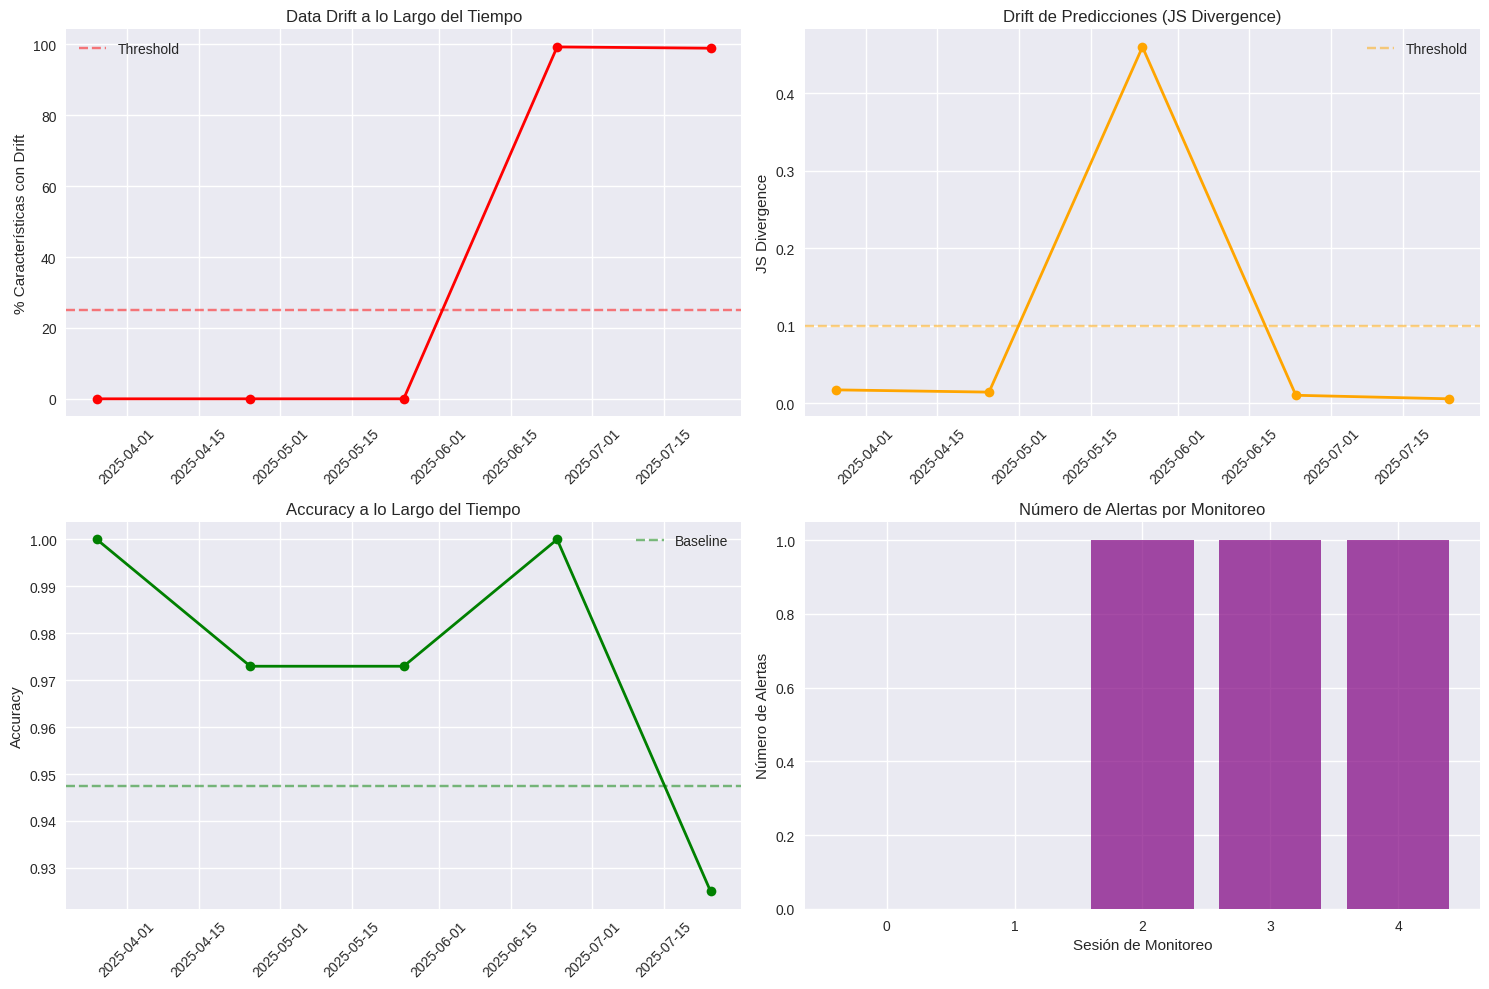

In [21]:
# ## 8. Simulación de Monitoreo a lo Largo del Tiempo

# %%
def simulate_monitoring_over_time(monitor, X_original, y_original, n_periods=5):
    """Simular monitoreo del modelo a lo largo del tiempo"""
    print("🕒 Simulando monitoreo a lo largo del tiempo...")

    # Dividir datos en períodos
    period_size = len(X_original) // n_periods

    for period in range(n_periods):
        start_idx = period * period_size
        end_idx = start_idx + period_size if period < n_periods - 1 else len(X_original)

        X_period = X_original[start_idx:end_idx]
        y_period = y_original[start_idx:end_idx]

        # Simular timestamp
        timestamp = datetime.now() - timedelta(days=(n_periods - period) * 30)

        print(f"\n--- Período {period + 1}/{n_periods} ---")

        # Añadir ruido progresivo para simular drift
        if period > 2:  # Empezar drift después del período 2
            noise_factor = (period - 2) * 0.1
            noise = np.random.normal(0, noise_factor, X_period.shape)
            X_period_noisy = X_period + noise
        else:
            X_period_noisy = X_period

        # Monitoreo completo
        results = monitor.comprehensive_monitoring(
            X_period_noisy, y_period, timestamp=timestamp
        )

        print(f"Datos procesados: {results['data_size']} muestras")

# Ejecutar simulación
simulate_monitoring_over_time(monitor, X, y, n_periods=5)

# Graficar historial
monitor.plot_monitoring_history()

In [22]:
# ## 9. Funciones de Predicción y Uso del Modelo

# %%
class MaintenancePredictionSystem:
    """Sistema completo de predicción para avisos de mantenimiento"""

    def __init__(self, model, preprocessor, monitor=None):
        self.model = model
        self.preprocessor = preprocessor
        self.monitor = monitor
        self.prediction_log = []

    def predict_single_notice(self, notice_data):
        """Predecir clase de un aviso individual"""
        # Convertir a DataFrame si es diccionario
        if isinstance(notice_data, dict):
            df_notice = pd.DataFrame([notice_data])
        else:
            df_notice = notice_data.copy()

        # Preprocesar
        X_notice = self.preprocessor.transform_new_data(df_notice)

        # Predicción
        prediction = self.model.predict(X_notice)[0]
        probabilities = self.model.predict_proba(X_notice)[0]

        # Decodificar predicción
        predicted_class = self.preprocessor.label_encoder.inverse_transform([prediction])[0]
        confidence = np.max(probabilities)

        # Crear diccionario de probabilidades por clase
        class_probabilities = {}
        for i, class_name in enumerate(self.preprocessor.label_encoder.classes_):
            class_probabilities[class_name] = probabilities[i]

        result = {
            'predicted_class': predicted_class,
            'confidence': confidence,
            'class_probabilities': class_probabilities,
            'timestamp': datetime.now()
        }

        # Log de predicción
        self.prediction_log.append(result)

        return result

    def predict_batch(self, notices_df):
        """Predecir clases para múltiples avisos"""
        print(f"🔮 Prediciendo {len(notices_df)} avisos...")

        # Preprocesar
        X_batch = self.preprocessor.transform_new_data(notices_df)

        # Predicciones
        predictions = self.model.predict(X_batch)
        probabilities = self.model.predict_proba(X_batch)

        # Decodificar
        predicted_classes = self.preprocessor.label_encoder.inverse_transform(predictions)
        confidences = np.max(probabilities, axis=1)

        # Crear DataFrame de resultados
        results_df = notices_df.copy()
        results_df['Prediccion_Clase'] = predicted_classes
        results_df['Confianza'] = confidences

        # Añadir probabilidades por clase
        for i, class_name in enumerate(self.preprocessor.label_encoder.classes_):
            results_df[f'Prob_{class_name}'] = probabilities[:, i]

        return results_df

    def get_prediction_insights(self, results_df=None):
        """Obtener insights de las predicciones realizadas"""
        if results_df is None and not self.prediction_log:
            print("No hay predicciones para analizar")
            return

        if results_df is not None:
            # Análisis de batch
            print("📊 INSIGHTS DE PREDICCIONES EN LOTE")
            print("-" * 50)

            # Distribución de predicciones
            pred_dist = results_df['Prediccion_Clase'].value_counts()
            print("Distribución de clases predichas:")
            for clase, count in pred_dist.items():
                pct = (count / len(results_df)) * 100
                print(f"  {clase}: {count} ({pct:.1f}%)")

            # Estadísticas de confianza
            print(f"\nEstadísticas de confianza:")
            print(f"  Media: {results_df['Confianza'].mean():.4f}")
            print(f"  Mediana: {results_df['Confianza'].median():.4f}")
            print(f"  Min: {results_df['Confianza'].min():.4f}")
            print(f"  Max: {results_df['Confianza'].max():.4f}")

            # Predicciones de baja confianza
            low_confidence = results_df[results_df['Confianza'] < 0.7]
            if len(low_confidence) > 0:
                print(f"\n⚠️  {len(low_confidence)} predicciones con confianza < 0.7")
                print("Revisar manualmente estos casos:")
                print(low_confidence[['Texto Breve del Aviso', 'Prediccion_Clase', 'Confianza']].head())

        else:
            # Análisis de log individual
            print("📊 INSIGHTS DE PREDICCIONES INDIVIDUALES")
            print("-" * 50)
            print(f"Total de predicciones: {len(self.prediction_log)}")

            classes = [pred['predicted_class'] for pred in self.prediction_log]
            confidences = [pred['confidence'] for pred in self.prediction_log]

            from collections import Counter
            class_counts = Counter(classes)

            print("Distribución de clases:")
            for clase, count in class_counts.items():
                pct = (count / len(classes)) * 100
                print(f"  {clase}: {count} ({pct:.1f}%)")

            print(f"\nConfianza promedio: {np.mean(confidences):.4f}")

    def save_system(self, filepath):
        """Guardar sistema completo"""
        system_data = {
            'model': self.model,
            'preprocessor': self.preprocessor,
            'monitor': self.monitor,
            'prediction_log': self.prediction_log,
            'timestamp': datetime.now()
        }

        joblib.dump(system_data, filepath)
        print(f"💾 Sistema guardado en: {filepath}")

    @classmethod
    def load_system(cls, filepath):
        """Cargar sistema previamente guardado"""
        system_data = joblib.load(filepath)

        system = cls(
            model=system_data['model'],
            preprocessor=system_data['preprocessor'],
            monitor=system_data.get('monitor')
        )

        system.prediction_log = system_data.get('prediction_log', [])

        print(f"📂 Sistema cargado desde: {filepath}")
        return system

# Crear sistema de predicción
prediction_system = MaintenancePredictionSystem(trainer.best_model, preprocessor, monitor)

In [23]:
# ## 10. Ejemplos de Uso y Predicciones

# %%
# Ejemplo 1: Predicción de un aviso individual
print("🎯 EJEMPLO 1: Predicción Individual")
print("-" * 40)

ejemplo_aviso = {
    'Ubicación Técnica': 'C-YB1-FUNCION',
    'Prioridad': 1,
    'Texto Breve del Aviso': 'Revisión preventiva de válvula de seguridad',
    'Área de empresa': 'ENE',
    'Grupo Planificacion': 'PL4',
    'Puesto de trabajo responsable': 'CVL-Z4',
    'Status Usuario Todos': 'AC',
    'Emplazamiento': 'VAPOI',
    'Activo Industrial': 'ENERGÍA',
    'Responsable Toma': 'ESP'
}

resultado = prediction_system.predict_single_notice(ejemplo_aviso)

print(f"Clase predicha: {resultado['predicted_class']}")
print(f"Confianza: {resultado['confidence']:.4f}")
print("\nProbabilidades por clase:")
for clase, prob in resultado['class_probabilities'].items():
    print(f"  {clase}: {prob:.4f}")

# %%
# Ejemplo 2: Predicción en lote con una muestra de datos originales
print("\n🎯 EJEMPLO 2: Predicción en Lote")
print("-" * 40)

# Usar una muestra de los datos originales (sin la columna objetivo)
sample_data = df_clean.head(10).drop(columns=['Responsable Toma'])
predictions_batch = prediction_system.predict_batch(sample_data)

# Mostrar resultados
print("Resultados de predicción en lote:")
display_cols = ['Texto Breve del Aviso', 'Prediccion_Clase', 'Confianza']
print(predictions_batch[display_cols])

# Insights
prediction_system.get_prediction_insights(predictions_batch)

🎯 EJEMPLO 1: Predicción Individual
----------------------------------------
Clase predicha: D2
Confianza: 0.8200

Probabilidades por clase:
  D1: 0.1800
  D2: 0.8200
  D5: 0.0000

🎯 EJEMPLO 2: Predicción en Lote
----------------------------------------
🔮 Prediciendo 10 avisos...
Resultados de predicción en lote:
                    Texto Breve del Aviso Prediccion_Clase  Confianza
0          YB1: sacamuestras agua y vapor               D2       0.99
1    Trasvasar glicol a bin | manualmente               D1       0.92
2  Trasladar glicol a coke I y Catalitico               D1       0.97
3   206-D SOLDAR TUERCAS EN TAPA INFERIOR               D2       1.00
4     Trasladar condensador de superficie               D1       0.70
5                     252C GIRAR FIGURA 8               D2       1.00
6         252J SE SOLICITA GIRAR FIGURA 8               D2       1.00
7                 Acondicionar tapa P.Out               D2       0.97
8     Adecuar cimentacion de HoA y pintar               

In [ ]:
# %%
def final_model_evaluation(trainer, preprocessor, prediction_system):
    """Evaluación final comprehensiva del modelo"""
    print("🏁 EVALUACIÓN FINAL DEL MODELO")
    print("=" * 60)

    best_model = trainer.best_model
    best_name = trainer.best_model_name

    # Métricas en conjunto de prueba
    y_pred = best_model.predict(trainer.X_test)
    y_proba = best_model.predict_proba(trainer.X_test)

    accuracy = accuracy_score(trainer.y_test, y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(
        trainer.y_test, y_pred, average='weighted'
    )

    print(f"🏆 MEJOR MODELO: {best_name}")
    print(f"📊 MÉTRICAS FINALES:")
    print(f"   • Accuracy: {accuracy:.4f}")
    print(f"   • Precision (weighted): {precision:.4f}")
    print(f"   • Recall (weighted): {recall:.4f}")
    print(f"   • F1-Score (weighted): {f1:.4f}")

    # Métricas por clase
    target_names = preprocessor.label_encoder.classes_
    precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(
        trainer.y_test, y_pred, average=None
    )

    print(f"\n📋 MÉTRICAS POR CLASE:")
    print("-" * 50)
    for i, class_name in enumerate(target_names):
        print(f"{class_name}:")
        print(f"  Precision: {precision_per_class[i]:.4f}")
        print(f"  Recall: {recall_per_class[i]:.4f}")
        print(f"  F1-Score: {f1_per_class[i]:.4f}")
        print(f"  Support: {support_per_class[i]}")
        print()

    # Análisis de errores
    print("🔍 ANÁLISIS DE ERRORES:")
    print("-" * 30)
    incorrect_predictions = trainer.y_test != y_pred
    error_rate = np.mean(incorrect_predictions)
    print(f"Tasa de error: {error_rate:.4f} ({np.sum(incorrect_predictions)} errores de {len(trainer.y_test)} predicciones)")

    if np.sum(incorrect_predictions) > 0:
        # Mostrar algunos errores
        error_indices = np.where(incorrect_predictions)[0][:5]  # Primeros 5 errores

        print("\nEjemplos de predicciones incorrectas:")
        for idx in error_indices:
            true_class = preprocessor.label_encoder.inverse_transform([trainer.y_test[idx]])[0]
            pred_class = preprocessor.label_encoder.inverse_transform([y_pred[idx]])[0]
            confidence = np.max(y_proba[idx])

            print(f"  • Real: {true_class} | Predicho: {pred_class} | Confianza: {confidence:.4f}")

    # Resumen del sistema
    print(f"\n🎯 RESUMEN DEL SISTEMA:")
    print("-" * 30)
    print(f"  • Características utilizadas: {trainer.X_train.shape[1]}")
    print(f"  • Clases objetivo: {len(target_names)}")
    print(f"  • Datos de entrenamiento: {trainer.X_train.shape[0]} muestras")
    print(f"  • Datos de prueba: {trainer.X_test.shape[0]} muestras")
    print(f"  • Predicciones realizadas: {len(prediction_system.prediction_log)}")

    # Recomendaciones
    print(f"\n💡 RECOMENDACIONES:")
    print("-" * 25)
    if accuracy > 0.9:
        print("  ✅ Excelente rendimiento del modelo")
    elif accuracy > 0.8:
        print("  ✅ Buen rendimiento del modelo")
    elif accuracy > 0.7:
        print("  ⚠️  Rendimiento aceptable - considerar mejoras")
    else:
        print("  ❌ Rendimiento bajo - revisar datos y modelo")

    if error_rate < 0.1:
        print("  ✅ Baja tasa de error")
    else:
        print("  ⚠️  Considerar análisis detallado de errores")

    print("  📈 Implementar monitoreo continuo")
    print("  🔄 Reentrenar periódicamente con nuevos datos")
    print("  📊 Revisar predicciones de baja confianza manualmente")

    return {
        'model_name': best_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'error_rate': error_rate,
        'n_features': trainer.X_train.shape[1],
        'n_classes': len(target_names),
        'training_samples': trainer.X_train.shape[0],
        'test_samples': trainer.X_test.shape[0]
    }

# Realizar evaluación final
final_results = final_model_evaluation(trainer, preprocessor, prediction_system)

In [ ]:
# ## 12. Guardado del Modelo y Sistema Completo

# %%
# Guardar el sistema completo
print("💾 GUARDANDO SISTEMA COMPLETO...")
print("-" * 40)

# Crear nombre de archivo con timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_filename = f"maintenance_classifier_{timestamp}.pkl"

# Guardar sistema
prediction_system.save_system(model_filename)

# Guardar también métricas y configuración
config_data = {
    'model_info': {
        'best_model_name': trainer.best_model_name,
        'training_timestamp': datetime.now(),
        'final_metrics': final_results
    },
    'data_info': {
        'original_shape': df.shape,
        'processed_shape': (len(X), len(X[0])),
        'target_classes': list(preprocessor.label_encoder.classes_),
        'feature_count': len(preprocessor.feature_names) if hasattr(preprocessor, 'feature_names') else 'unknown'
    },
    'preprocessing_config': {
        'target_column': preprocessor.target_column,
        'has_text_features': hasattr(preprocessor, 'tfidf_vectorizer'),
        'has_structured_features': preprocessor.preprocessor is not None
    }
}

config_filename = f"model_config_{timestamp}.json"
with open(config_filename, 'w', encoding='utf-8') as f:
    json.dump(config_data, f, indent=2, default=str)

print(f"✅ Sistema guardado como: {model_filename}")
print(f"✅ Configuración guardada como: {config_filename}")



In [ ]:

# ## 13. Instrucciones de Uso Futuro

# %%
print("📖 INSTRUCCIONES DE USO FUTURO")
print("=" * 50)

print("""
🔄 PARA USAR EL MODELO EN PRODUCCIÓN:

1. CARGAR SISTEMA:
   ```python
   from maintenance_classifier import MaintenancePredictionSystem
   system = MaintenancePredictionSystem.load_system('maintenance_classifier_YYYYMMDD_HHMMSS.pkl')
   ```

2. PREDICCIÓN INDIVIDUAL:
   ```python
   aviso = {
       'Ubicación Técnica': 'C-YB1-FUNCION',
       'Prioridad': 1,
       'Texto Breve del Aviso': 'Descripción del problema',
       # ... otros campos
   }
   resultado = system.predict_single_notice(aviso)
   print(f"Clase: {resultado['predicted_class']}")
   print(f"Confianza: {resultado['confidence']}")
   ```

3. PREDICCIÓN EN LOTE:
   ```python
   df_nuevos = pd.read_csv('nuevos_avisos.csv')
   resultados = system.predict_batch(df_nuevos)
   ```

4. MONITOREO CONTINUO:
   ```python
   # Verificar drift y rendimiento
   if system.monitor:
       system.monitor.comprehensive_monitoring(X_nuevos, y_verdaderos)
   ```

📋 MANTENIMIENTO RECOMENDADO:

• Revisar rendimiento mensualmente
• Reentrenar con nuevos datos cada 3-6 meses
• Monitorear predicciones de baja confianza (<0.7)
• Actualizar umbrales de alerta según sea necesario
• Documentar cambios en los datos o procesos

⚠️  CONSIDERACIONES IMPORTANTES:

• El modelo fue entrenado con datos específicos del período actual
• Cambios en los procesos de mantenimiento pueden requerir reentrenamiento
• Siempre validar predicciones críticas manualmente
• Mantener respaldo de versiones anteriores del modelo
""")

print(f"""
📊 RESUMEN FINAL:
• Modelo seleccionado: {trainer.best_model_name}
• Accuracy final: {final_results['accuracy']:.4f}
• Características utilizadas: {final_results['n_features']}
• Clases objetivo: {final_results['n_classes']}
• Archivo del modelo: {model_filename}

🎉 ¡Sistema de clasificación listo para producción!
""")

# %%
print("✅ NOTEBOOK COMPLETADO EXITOSAMENTE")
print("="*50)
print("El sistema de clasificación de avisos de mantenimiento ha sido")
print("entrenado, evaluado y está listo para usar en producción.")
print("\nArchivos generados:")
print(f"  • {model_filename} (modelo y sistema completo)")
print(f"  • {config_filename} (configuración y métricas)")
print("\n¡Gracias por usar el clasificador de avisos de mantenimiento! 🔧⚙️")